In [3]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN


In [4]:
symbols = pd.read_csv("symbols.csv")['Symbol'].tolist()
netAssets = pd.read_csv("net_assets.csv")
closes = pd.read_csv("closes.csv", index_col=0)

netAssets['Inception Date'] = pd.to_datetime(netAssets['Inception Date'])
netAssets = netAssets[netAssets['Inception Date'] <= pd.Timestamp('2011-01-01')]
goodSymbols = netAssets['Symbol'].tolist()
goodCloses = closes[goodSymbols]
goodCloses = goodCloses.loc['2010-09-22':]

**I need to find clusters for hyperparameter tuning for like ETFs. If I do it on a per ETF instance, it becomes way to susceptible to overfitting, but if I do it on a generalized basis, it doesn't allow for good convergence. I am choosing DBSCAN because it can handle noise and I don't know how many clusters there will be.**

In [5]:
returns = goodCloses.pct_change().dropna()
corr = returns.corr()
dist = np.sqrt(2 * (1 - corr))



In [6]:
#DBSCAN Clustering
DBmodel = DBSCAN(eps=0.5, min_samples=2, metric='precomputed')
DBclusters = DBmodel.fit_predict(dist)

uniqueClusters = set(DBclusters)
for cluster in uniqueClusters:
    if cluster == -1:
        print("No fit:")
    else:
        print(f"Cluster {cluster + 1}:")
    clusterSymbols = [goodSymbols[j] for j in range(len(goodSymbols)) if DBclusters[j] == cluster]
    print(f"{', '.join(clusterSymbols)}")


Cluster 1:
VONG, VOO, VOOG, TQQQ, SCHG, SCHF, SCHX, SCHB, VT, ACWI, MGK, VEA, SPDW, VEU, VYM, VIG, EFV, VWO, VGK, VV, VTV, VO, VBR, VUG, VGT, VB, ITOT, RSP, EEM, VXF, EFA, IWR, SOXX, VTI, SPYG, SPYV, IUSG, IJR, IWF, IWM, IVE, IWD, IVW, IJH, IVV, IWB, QQQ, XLK, XLI, XLF, DIA, MDY, SPY
Cluster 2:
VCIT, VGIT, BND, BIV, AGG, LQD, TLT, IEF
Cluster 3:
IAU, GLD
No fit:
VCSH, VGSH, MUB, BIL, BSV, MBB, GDX, SLV, VNQ, XLV, XLE


**I like that the DBSCAN algorithm gave me two strong clusters. The third is ehh whatever, but interesting in the fact that the ETFs in cluster 3 don't cluster well with those in 'Noise' because it is gold based. With that, I'm going to manually make the three clusters as this:

Cluster 1: [VONG, VOO, VOOG, TQQQ, SCHG, SCHF, SCHX, SCHB, VT, ACWI, MGK, DFAC, VEA, SPDW, VEU, VYM, VIG, EFV, VWO, VGK, VV, VTV, VO, VBR, VUG, VGT, VB, ITOT, RSP, EEM, VXF, EFA, IWR, SOXX, VTI, SPYG, SPYV, IUSG, IJR, IWF, IWM, IVE, IWD, IVW, IJH, IVV, IWB, QQQ, XLK, XLI, XLF, DIA, MDY, SPY, **XLV**, **XLE**]

Cluster 2: [VCIT, VGIT, VCSH, VGSH, BND, BSV, BIV, MBB, AGG, LQD, TLT, IEF, **MUB**, **BIL**, ]

Cluster 3: [IAU, GLD, **GDX**, **SLV**]


Note MUB and BIL made it into cluster 2 because this is entirely comprised of fixed income ETFs

GDX and SLV made it into cluster 3 becaus these comprise of Gold and Silver ETFs

XLV and XLE made it into cluster 1 because they don't belong in 1 or 2, but additonally, other subsector ETFs are in cluster 1


In [7]:
def stochastic(df, n=14):
    low = df['Close'].rolling(window=n).min()
    high = df['Close'].rolling(window=n).max()

    dnom = high - low
    dnom = dnom.replace(0, 1e-9)

    k = (df['Close'] - low) / dnom * 100
    d = k.rolling(window=3).mean()

    return k, d

def calcRegimeFilter(df):
    df = df.copy()

    df['Bull Regime'] = df['Close'] > df['SMA_200']
    df['Bear Regime'] = df['Close'] < df['SMA_200']

    df['High Volatility Regime'] = df['vol_20'] > df['vol_50']
    df['Low Volatility Regime'] = df['vol_20'] < df['vol_50']

    df['Regime'] = np.select(
        [
            (df['Bull Regime'] & df['Low Volatility Regime']),
            (df['Bull Regime'] & df['High Volatility Regime']),
            (df['Bear Regime'] & df['Low Volatility Regime']),
            (df['Bear Regime'] & df['High Volatility Regime'])
        ],
        [
            'Bull-Low Vol',
            'Bull-High Vol',
            'Bear-Low Vol',
            'Bear-High Vol'
        ],
        default='No Regime'
    )

    

    return df

def getTarget(df):
    df = df.copy()
    df['Target'] = np.where(df['Returns'].shift(-1) > 0, 1, 0)
    return df

def getTechnicalData(closes):
    df = pd.DataFrame()
    df['Close'] = closes
    df['Returns'] = closes.pct_change()
    df['SMA_20'] = closes.rolling(window=20).mean()
    df['SMA_50'] = closes.rolling(window=50).mean()
    df['SMA_200'] = closes.rolling(window=200).mean()

    df['vol_20'] = closes.rolling(window=20).std()
    df['vol_50'] = closes.rolling(window=50).std()

    df = calcRegimeFilter(df)
    df['K'], df['D'] = stochastic(df)
    df['K_minus_D'] = df['K'] - df['D']
    df['K_cross_D'] = np.where((df['K'] > df['D']) & (df['K'].shift(1) <= df['D'].shift(1)), 1, 0)
    df['dist_ma'] = (df['Close'] - df['SMA_200']) / df['SMA_200']
    df['vol_ratio'] = df['vol_20'] / df['vol_50']
    df['Target'] = np.where(df['Returns'].shift(-1) > 0, 1, 0)

    return df.dropna()






In [8]:
#Test for the big loop

spyTest = goodCloses['SPY']
technicalSPY = getTechnicalData(spyTest)
dummyVars = pd.get_dummies(technicalSPY['Regime']).astype(int)
dummyVars['Standardized Regime'] = np.where(
    technicalSPY['Regime'] == 'Bull-Low Vol', 0, np.where(
        technicalSPY['Regime'] == 'Bull-High Vol', 1, np.where(
            technicalSPY['Regime'] == 'Bear-Low Vol', 2, np.where(
                technicalSPY['Regime'] == 'Bear-High Vol', 3, 4
            )
        )
    )
)
technicalSPY = pd.concat([technicalSPY, dummyVars['Standardized Regime']], axis=1)
technicalSPY




,Close,Returns,SMA_20,SMA_50,SMA_200,vol_20,vol_50,Bull Regime,Bear Regime,High Volatility Regime,Low Volatility Regime,Regime,K,D,K_minus_D,K_cross_D,dist_ma,vol_ratio,Target,Standardized Regime
Date,,,,,,,,,,,,,,,,,,,,
2011-07-07,135.360001,0.010375,129.681000,131.956599,127.282450,2.698007,3.024643,True,False,False,True,Bull-Low Vol,100.000000,99.484292,0.515708,0,0.063462,0.892008,0,0
2011-07-08,134.399994,-0.007092,129.931000,131.931199,127.387350,2.895055,2.998038,True,False,False,True,Bull-Low Vol,88.771855,96.257285,-7.485430,0,0.055050,0.965650,0,0
2011-07-11,131.970001,-0.018080,130.149500,131.848399,127.484700,2.874705,2.936817,True,False,False,True,Bull-Low Vol,60.350898,83.040918,-22.690019,0,0.035183,0.978851,0,0
2011-07-12,131.399994,-0.004319,130.334500,131.747799,127.567600,2.827439,2.861867,True,False,False,True,Bull-Low Vol,53.684149,67.602301,-13.918152,0,0.030042,0.987970,1,0
2011-07-13,131.839996,0.003349,130.460499,131.660199,127.655450,2.835987,2.788270,True,False,True,False,Bull-High Vol,58.830374,57.621807,1.208567,1,0.032780,1.017114,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-20,708.719971,-0.002000,669.624500,675.613400,666.918199,24.233857,18.108583,True,False,True,False,Bull-High Vol,97.625344,99.208448,-1.583104,0,0.062679,1.338252,0,1
2026-04-21,704.080017,-0.006547,672.059500,675.882600,667.311899,25.156362,18.433358,True,False,True,False,Bull-High Vol,88.961758,95.529034,-6.567276,0,0.055099,1.364719,1,1
2026-04-22,711.210022,0.010127,674.961002,676.227800,667.764549,26.189554,18.933440,True,False,True,False,Bull-High Vol,100.000000,95.529034,4.470966,1,0.065061,1.383243,0,1


In [9]:
goodCloses

,VONG,VOO,VOOG,TQQQ,SCHG,VCIT,VGIT,VCSH,VGSH,SCHF,...,IWB,QQQ,XLK,XLI,XLF,XLV,XLE,DIA,MDY,SPY
Date,,,,,,,,,,,,,,,,,,,,,
2010-09-22,12.952500,104.160004,8.745000,0.278620,3.315000,81.510002,63.560001,78.370003,60.849998,12.960000,...,62.910000,48.689999,11.355000,31.059999,11.787165,30.410000,27.219999,107.400002,142.070007,113.419998
2010-09-23,12.987500,103.300003,8.725000,0.277786,3.296250,81.510002,63.689999,78.250000,60.830002,12.820000,...,62.119999,48.669998,11.340000,30.600000,11.559708,30.250000,27.049999,106.669998,141.080002,112.500000
2010-09-24,13.147500,104.839996,8.890000,0.293516,3.370000,81.199997,63.439999,78.330002,60.740002,13.155000,...,63.389999,49.660000,11.560000,31.440001,11.868400,30.660000,27.635000,108.570000,144.419998,114.820000
2010-09-27,13.187500,104.339996,8.865000,0.290156,3.355000,81.599998,63.680000,78.389999,60.860001,13.105000,...,63.150002,49.389999,11.565000,31.240000,11.738424,30.430000,27.530001,108.190002,144.419998,114.269997
2010-09-28,13.187500,105.019997,8.896667,0.290885,3.375000,81.949997,63.930000,78.430000,60.830002,13.195000,...,63.389999,49.369999,11.580000,31.410000,11.762794,30.680000,27.725000,108.559998,145.350006,114.669998
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-20,122.169998,651.539978,76.743332,58.080002,32.540001,83.500000,59.720001,79.500000,58.570000,26.760000,...,388.519989,646.789978,154.559998,173.899994,52.630001,147.419998,55.070000,494.329987,669.580017,708.719971
2026-04-21,121.279999,647.250000,76.250000,57.400002,32.330002,83.220001,59.520000,79.370003,58.500000,26.180000,...,385.880005,644.330017,154.690002,171.440002,52.299999,145.919998,55.869999,491.359985,665.619995,704.080017
2026-04-22,123.209999,653.900024,77.599998,60.209999,32.849998,83.309998,59.560001,79.419998,58.500000,26.400000,...,389.660004,655.109985,158.089996,171.039993,52.209999,146.380005,56.540001,494.760010,663.090027,711.210022


In [10]:
technicalData = {}

for symbol in goodSymbols:
    technicalDF = getTechnicalData(goodCloses[symbol])
    dummyVars = pd.get_dummies(technicalDF['Regime']).astype(int)
    dummyVars['Standardized Regime'] = np.where(
        technicalDF['Regime'] == 'Bull-Low Vol', 0, np.where(
            technicalDF['Regime'] == 'Bull-High Vol', 1, np.where(
                technicalDF['Regime'] == 'Bear-Low Vol', 2, np.where(
                    technicalDF['Regime'] == 'Bear-High Vol', 3, 4
                    )
                )
            )
    )
    technicalDF = pd.concat([technicalDF, dummyVars['Standardized Regime']], axis=1)
    technicalData[symbol] = technicalDF




In [11]:
clusterOne = ['VONG', 'VOO', 'VOOG', 'TQQQ', 'SCHG', 'SCHF', 'SCHX', 'SCHB', 'VT', 'ACWI', 'MGK', 'DFAC', 'VEA', 'SPDW', 'VEU', 'VYM', 'VIG', 'EFV', 'VWO', 'VGK', 'VV', 'VTV', 'VO', 'VBR', 'VUG', 'VGT', 'VB', 'ITOT', 'RSP', 'EEM', 'VXF', 'EFA', 'IWR', 'SOXX', 'VTI', 'SPYG', 'SPYV', 'IUSG', 'IJR', 'IWF', 'IWM', 'IVE', 'IWD', 'IVW', 'IJH', 'IVV', 'IWB', 'QQQ', 'XLK', 'XLI', 'XLF', 'DIA', 'MDY', 'SPY', 'XLV', 'XLE']
clusterTwo = ['VCIT', 'VGIT', 'VCSH', 'VGSH', 'BND', 'BSV', 'BIV', 'MBB', 'AGG', 'LQD', 'TLT', 'IEF', 'MUB', 'BIL']
clusterThree = ['IAU', 'GLD', 'GDX', 'SLV']

In [12]:
trainedModels = {}
logisticRegressionFeatures = [] 
features = ['K', 'D', 'K_minus_D', 'K_cross_D', 'dist_ma', 'vol_ratio', 'Standardized Regime'] 

XTrainDict = {}
XTestDict = {}
YTrainDict = {}
YTestDict = {}


for symbol in goodSymbols:
    df = technicalData[symbol].copy()
    X = df[features]
    y = df['Target']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    XTrainDict[symbol] = X_train_scaled
    XTestDict[symbol] = X_test_scaled
    YTrainDict[symbol] = y_train
    YTestDict[symbol] = y_test

    model = LogisticRegression()
    model.fit(X_train_scaled, y_train)

    trainedModels[symbol] = model

    print(f'Train Accuracy for {symbol}: {model.score(X_train_scaled, y_train):.4f},  Test Accuracy for {symbol}: {model.score(X_test_scaled, y_test):.4f}')
    



Train Accuracy for VONG: 0.5563,  Test Accuracy for VONG: 0.5772
Train Accuracy for VOO: 0.5395,  Test Accuracy for VOO: 0.5544
Train Accuracy for VOOG: 0.5576,  Test Accuracy for VOOG: 0.5919
Train Accuracy for TQQQ: 0.5492,  Test Accuracy for TQQQ: 0.5758
Train Accuracy for SCHG: 0.5435,  Test Accuracy for SCHG: 0.5772
Train Accuracy for VCIT: 0.5173,  Test Accuracy for VCIT: 0.4926
Train Accuracy for VGIT: 0.5297,  Test Accuracy for VGIT: 0.5087
Train Accuracy for VCSH: 0.5244,  Test Accuracy for VCSH: 0.5007
Train Accuracy for VGSH: 0.5885,  Test Accuracy for VGSH: 0.5302
Train Accuracy for SCHF: 0.5200,  Test Accuracy for SCHF: 0.5356
Train Accuracy for SCHX: 0.5378,  Test Accuracy for SCHX: 0.5530
Train Accuracy for SCHB: 0.5361,  Test Accuracy for SCHB: 0.5477
Train Accuracy for VT: 0.5364,  Test Accuracy for VT: 0.5584
Train Accuracy for ACWI: 0.5344,  Test Accuracy for ACWI: 0.5584
Train Accuracy for MGK: 0.5479,  Test Accuracy for MGK: 0.5772
Train Accuracy for MUB: 0.5465,  

In [13]:
def getSharpeRatio(returns, risk_free_rate=0.0,periods_per_year=252):
    returns = pd.Series(returns).dropna()
    if len(returns) == 0:

        return np.nan
    excess_returns = returns - (risk_free_rate / periods_per_year)
    volatility = excess_returns.std(ddof=1)
    if volatility == 0:
        return np.nan
    
    annualized_excess_return = excess_returns.mean() * periods_per_year
    annualized_volatility = volatility * np.sqrt(periods_per_year)

    return annualized_excess_return / annualized_volatility

def getTrades(signaledProbabilities):
    probabilities = pd.DataFrame(signaledProbabilities)
    probabilities.set_index(goodCloses.index[-745:])

    signaledTrades = probabilities.where((probabilities > 0.55) | (probabilities < 0.45))

    longTrades = signaledTrades.where(signaledTrades > 0.5)
    longTrades.index = goodCloses.index[-745:]
    longTrades = longTrades[:-1]

    shortTrades = signaledTrades.where(signaledTrades < 0.5)
    shortTrades.index = goodCloses.index[-745:]
    shortTrades = shortTrades[:-1]

    returns = closes.pct_change().shift(-1)
    returns = returns.loc[shortTrades.index[0]:]
    shortReturns = -1 * returns.where(shortTrades > 0)
    longReturns = returns.where(longTrades > 0)
    combinedReturns = longReturns.fillna(0) + shortReturns.fillna(0)


    trades = (combinedReturns != 0).sum(axis=1)
    return combinedReturns, trades

In [14]:
LRprobabilities = {}
for symbol in goodSymbols:
    LRprobabilities[symbol] = trainedModels[symbol].predict_proba(XTestDict[symbol])[:, 1]

LRTrades, LRTradesAGG = getTrades(LRprobabilities)

dailyReturns = LRTrades.sum(axis=1) / LRTradesAGG
dailyReturns = dailyReturns.fillna(0)

sharpeRatio = getSharpeRatio(dailyReturns.values)
sharpeRatio


np.float64(1.3772434934506401)

In [15]:
sp500 = pd.read_csv('S&P500.csv')
sp500 = sp500.set_index('Date')
sp500Return = sp500.pct_change().dropna()

spWealthIndex = (sp500Return['^GSPC']+1).cumprod()
spSharpeRatio = getSharpeRatio(sp500Return['^GSPC'], periods_per_year=252)


<Axes: xlabel='Date'>

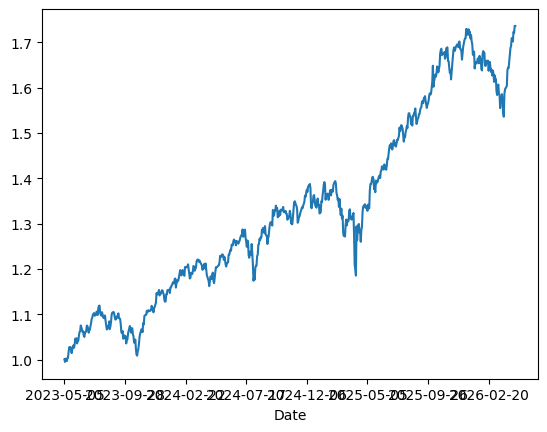

In [16]:
wealthIndex = (dailyReturns+1).cumprod()
wealthIndex.plot()

In [17]:
print(f'''This strategy yielded a {100*(wealthIndex.iloc[-1] - wealthIndex.iloc[0]/wealthIndex.iloc[0])}% return\n
      the S&P 500 had yieled a {100*(spWealthIndex.iloc[-1] - spWealthIndex.iloc[0]/spWealthIndex.iloc[0])}% return''')

This strategy yielded a 73.57495276078279% return

      the S&P 500 had yieled a 71.85614753324268% return


In [18]:
def plot_drawdown(returns, title="Strategy Drawdown", starting_value=1):
    rets = pd.Series(returns).dropna()

    wealth_index = starting_value * (1 + rets).cumprod()
    previous_peaks = wealth_index.cummax()
    drawdowns = (wealth_index - previous_peaks) / previous_peaks

    max_drawdown = drawdowns.min()
    max_drawdown_date = drawdowns.idxmin()

    fig, ax1 = plt.subplots(figsize=(12, 6))

    ax1.plot(wealth_index, label="Wealth Index")
    ax1.plot(previous_peaks, label="Previous Peaks")
    ax1.set_ylabel("Wealth Index")
    ax1.set_title(title)

    ax2 = ax1.twinx()
    ax2.plot(drawdowns, label="Drawdown", alpha=0.6)
    ax2.set_ylabel("Drawdown")

    ax2.annotate(
        f"Max Drawdown: {max_drawdown:.2%}",
        xy=(max_drawdown_date, max_drawdown),
        xytext=(max_drawdown_date, max_drawdown * 0.5),
        arrowprops=dict(arrowstyle="->", lw=1),
    )

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

    plt.show()

    return {
        "wealth_index": wealth_index,
        "previous_peaks": previous_peaks,
        "drawdowns": drawdowns,
        "max_drawdown": max_drawdown,
        "max_drawdown_date": max_drawdown_date
    }

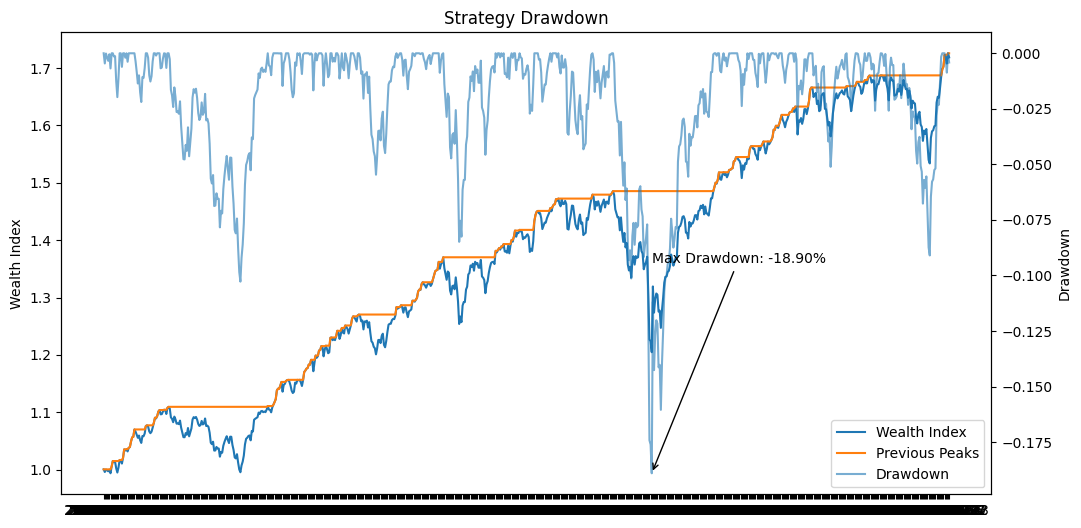

{'wealth_index': Date
 2023-05-08    1.000452
 2023-05-09    0.995871
 2023-05-10    1.000336
 2023-05-11    0.998639
 2023-05-12    0.997058
                 ...   
 2026-04-17    1.722831
 2026-04-20    1.718740
 2026-04-21    1.707829
 2026-04-22    1.725694
 2026-04-23    1.718561
 Name: ^GSPC, Length: 743, dtype: float64,
 'previous_peaks': Date
 2023-05-08    1.000452
 2023-05-09    1.000452
 2023-05-10    1.000452
 2023-05-11    1.000452
 2023-05-12    1.000452
                 ...   
 2026-04-17    1.722831
 2026-04-20    1.722831
 2026-04-21    1.722831
 2026-04-22    1.725694
 2026-04-23    1.725694
 Name: ^GSPC, Length: 743, dtype: float64,
 'drawdowns': Date
 2023-05-08    0.000000
 2023-05-09   -0.004579
 2023-05-10   -0.000116
 2023-05-11   -0.001812
 2023-05-12   -0.003393
                 ...   
 2026-04-17    0.000000
 2026-04-20   -0.002374
 2026-04-21   -0.008708
 2026-04-22    0.000000
 2026-04-23   -0.004133
 Name: ^GSPC, Length: 743, dtype: float64,
 'max_drawdown

In [19]:
plot_drawdown(sp500Return['^GSPC'])

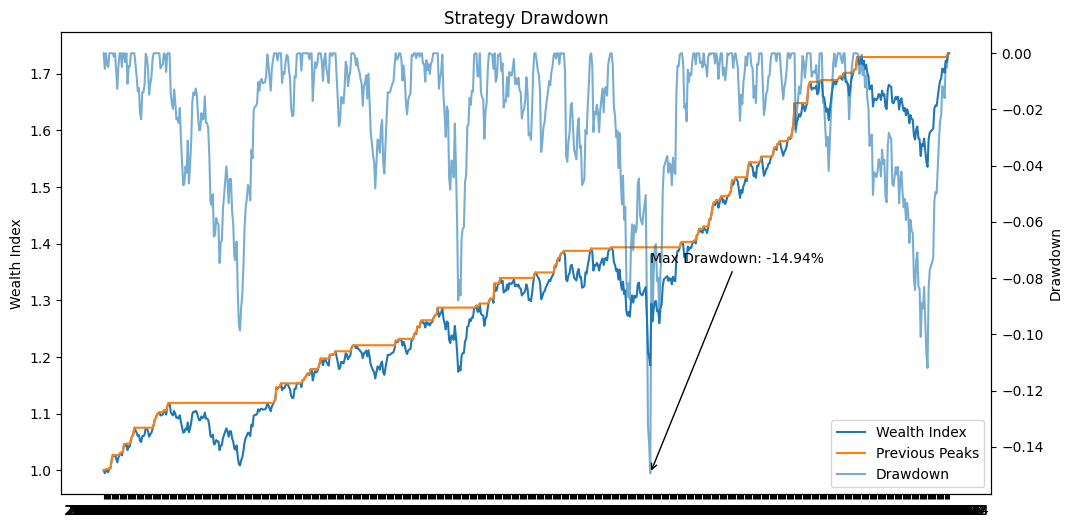

{'wealth_index': Date
 2023-05-05    1.000610
 2023-05-08    0.995052
 2023-05-09    1.002097
 2023-05-10    0.997997
 2023-05-11    0.997179
                 ...   
 2026-04-20    1.701467
 2026-04-21    1.722844
 2026-04-22    1.720191
 2026-04-23    1.735750
 2026-04-24    1.735750
 Length: 745, dtype: float64,
 'previous_peaks': Date
 2023-05-05    1.000610
 2023-05-08    1.000610
 2023-05-09    1.002097
 2023-05-10    1.002097
 2023-05-11    1.002097
                 ...   
 2026-04-20    1.729106
 2026-04-21    1.729106
 2026-04-22    1.729106
 2026-04-23    1.735750
 2026-04-24    1.735750
 Length: 745, dtype: float64,
 'drawdowns': Date
 2023-05-05    0.000000
 2023-05-08   -0.005555
 2023-05-09    0.000000
 2023-05-10   -0.004092
 2023-05-11   -0.004908
                 ...   
 2026-04-20   -0.015984
 2026-04-21   -0.003621
 2026-04-22   -0.005156
 2026-04-23    0.000000
 2026-04-24    0.000000
 Length: 745, dtype: float64,
 'max_drawdown': np.float64(-0.1494097562171308),
 'm

In [20]:
plot_drawdown(dailyReturns)

In [21]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

In [22]:
XGBOOSTXTrainDict = {}
XGBOOSTXTestDict = {}
XGBOOSTYTrainDict = {}
XGBOOSTYTestDict = {}
XGModels = {}
XGProbabilities = {}

for symbol in goodSymbols:
    df = technicalData[symbol].copy()
    X = df[features]
    y = df['Target']

    XTrain, XTest, yTrain, yTest = train_test_split(X, y, test_size=0.2, shuffle=False)

    scaler = StandardScaler()
    

    XGBOOSTXTrainDict[symbol] = X_train
    XGBOOSTXTestDict[symbol] = X_test
    XGBOOSTYTrainDict[symbol] = y_train
    XGBOOSTYTestDict[symbol] = y_test

    model = XGBClassifier(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.02,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss"
        )

    model.fit(XTrain, yTrain)

    XGModels[symbol] = model

    XGProbabilities[symbol] = pd.Series(
        model.predict_proba(XTest)[:, 1]
    )
    print(f'Train Accuracy for {symbol}: {model.score(XTrain, yTrain):.4f},  Test Accuracy for {symbol}: {model.score(XTest, yTest):.4f}')


    

Train Accuracy for VONG: 0.6584,  Test Accuracy for VONG: 0.5611
Train Accuracy for VOO: 0.6705,  Test Accuracy for VOO: 0.5275
Train Accuracy for VOOG: 0.6658,  Test Accuracy for VOOG: 0.5785
Train Accuracy for TQQQ: 0.6695,  Test Accuracy for TQQQ: 0.5691
Train Accuracy for SCHG: 0.6668,  Test Accuracy for SCHG: 0.5745
Train Accuracy for VCIT: 0.7188,  Test Accuracy for VCIT: 0.5114
Train Accuracy for VGIT: 0.7071,  Test Accuracy for VGIT: 0.4940
Train Accuracy for VCSH: 0.6829,  Test Accuracy for VCSH: 0.4899
Train Accuracy for VGSH: 0.6668,  Test Accuracy for VGSH: 0.5047
Train Accuracy for SCHF: 0.6822,  Test Accuracy for SCHF: 0.5181
Train Accuracy for SCHX: 0.6755,  Test Accuracy for SCHX: 0.5275
Train Accuracy for SCHB: 0.6775,  Test Accuracy for SCHB: 0.5195
Train Accuracy for VT: 0.6722,  Test Accuracy for VT: 0.5289
Train Accuracy for ACWI: 0.6681,  Test Accuracy for ACWI: 0.5020
Train Accuracy for MGK: 0.6661,  Test Accuracy for MGK: 0.5691
Train Accuracy for MUB: 0.6779,  

In [23]:
XGTrades, XGTradesAGG = getTrades(XGProbabilities)

XGdailyReturns = XGTrades.sum(axis=1) / XGTradesAGG
XGdailyReturns = XGdailyReturns.fillna(0)

XGsharpeRatio = getSharpeRatio(XGdailyReturns.values)
XGsharpeRatio


np.float64(1.5692822351447604)

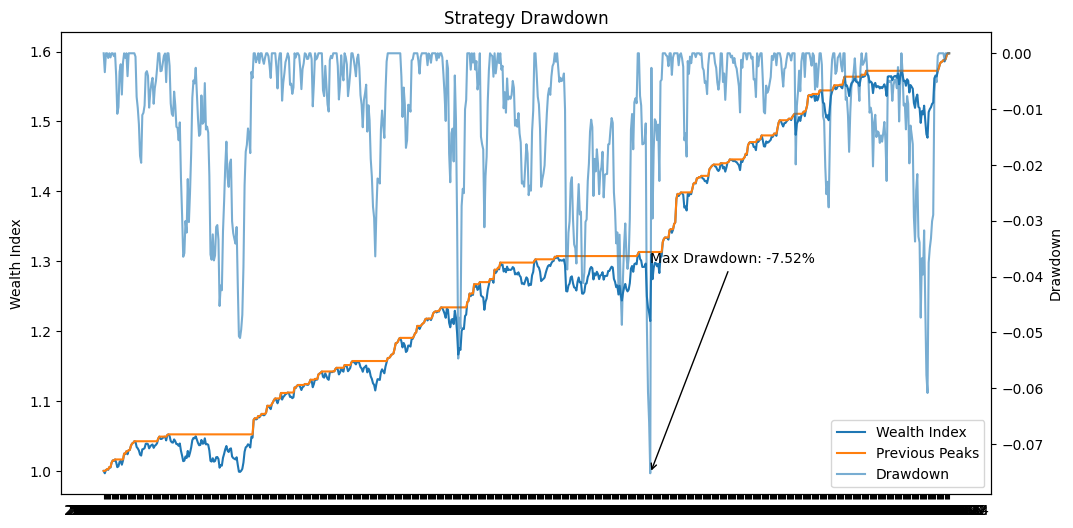

{'wealth_index': Date
 2023-05-05    1.000412
 2023-05-08    0.997027
 2023-05-09    1.001648
 2023-05-10    1.002783
 2023-05-11    1.001941
                 ...   
 2026-04-20    1.585883
 2026-04-21    1.589688
 2026-04-22    1.595400
 2026-04-23    1.597520
 2026-04-24    1.597520
 Length: 745, dtype: float64,
 'previous_peaks': Date
 2023-05-05    1.000412
 2023-05-08    1.000412
 2023-05-09    1.001648
 2023-05-10    1.002783
 2023-05-11    1.002783
                 ...   
 2026-04-20    1.587816
 2026-04-21    1.589688
 2026-04-22    1.595400
 2026-04-23    1.597520
 2026-04-24    1.597520
 Length: 745, dtype: float64,
 'drawdowns': Date
 2023-05-05    0.000000
 2023-05-08   -0.003383
 2023-05-09    0.000000
 2023-05-10    0.000000
 2023-05-11   -0.000840
                 ...   
 2026-04-20   -0.001217
 2026-04-21    0.000000
 2026-04-22    0.000000
 2026-04-23    0.000000
 2026-04-24    0.000000
 Length: 745, dtype: float64,
 'max_drawdown': np.float64(-0.07522219022265127),
 '

In [24]:
plot_drawdown(XGdailyReturns)

In [25]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import time
torch.set_num_threads(1)
torch.set_num_interop_threads(1)
device = torch.device("cpu")


In [26]:
def makeSequences(X, y, lookback=20):
    XSeq = []
    ySeq = []

    for i in range(lookback, len(X)):
        XSeq.append(X[i-lookback:i])
        ySeq.append(y.iloc[i])

    return np.array(XSeq), np.array(ySeq)

class LSTMModel(nn.Module):
    def __init__(self, inputSize, hiddenSize, numLayers):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=inputSize,
            hidden_size=hiddenSize,
            num_layers=numLayers,
            batch_first=True
        )

        self.fc = nn.Linear(hiddenSize, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)

        return out

# Training all RNN at once

In [27]:
LSTMProbs = {}

for symbol in goodSymbols:
    print(symbol)
    nnX = technicalData[symbol][features].copy()
    nny = technicalData[symbol]['Target'].copy()

    nnScaler = StandardScaler()
    nnX = scaler.fit_transform(nnX)

    nnXSeq, nnySeq = makeSequences(nnX, nny, 20)

    split = -745

    nnXTrain = nnXSeq[:split]
    nnXTest = nnXSeq[split:]

    nnyTrain = nnySeq[:split]
    nnyTest = nnySeq[split:]

    nnXTrain = np.asarray(nnXTrain, dtype=np.float32)
    nnXTest = np.asarray(nnXTest, dtype=np.float32)

    nnyTrain = np.asarray(nnyTrain, dtype=np.float32)
    nnyTest = np.asarray(nnyTest, dtype=np.float32)

    nnXTrain = torch.from_numpy(nnXTrain)
    nnXTest = torch.from_numpy(nnXTest)

    nnyTrain = torch.from_numpy(nnyTrain)
    nnyTest = torch.from_numpy(nnyTest)

    inputSize = nnXTrain.shape[2]

    NNModel = LSTMModel(inputSize=inputSize, hiddenSize=16, numLayers=1)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(NNModel.parameters(), lr=0.001)


    NNModel = NNModel.to(device)

    nnXTrain = nnXTrain.to(device)
    nnyTrain = nnyTrain.to(device)

    trainDataset = TensorDataset(nnXTrain, nnyTrain)
    trainLoader = DataLoader(trainDataset, batch_size=64, shuffle=False)


    epochs = 50

    for epoch in range(epochs):
        start = time.time()
        NNModel.train()
        epochLoss = 0

        for batchX, batchY in trainLoader:
            batchY = batchY.view(-1, 1)

            outputs = NNModel(batchX)
            loss = criterion(outputs, batchY)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epochLoss += loss.item()

        end = time.time()

        '''if (epoch % 5) == 0:
            print(symbol, epoch)'''


    NNModel.eval()
    with torch.no_grad():
        logits = NNModel(nnXTest)
        probs = torch.sigmoid(logits).squeeze().numpy()
        LSTMProbs[symbol] = probs

VONG


/var/folders/n_/rrztng4d5bx940t8yvm1rmz00000gq/T/ipykernel_7077/2113863543.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ySeq.append(y[i])


VOO


/var/folders/n_/rrztng4d5bx940t8yvm1rmz00000gq/T/ipykernel_7077/2113863543.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ySeq.append(y[i])


VOOG


...

/var/folders/n_/rrztng4d5bx940t8yvm1rmz00000gq/T/ipykernel_7077/2113863543.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ySeq.append(y[i])


MDY


/var/folders/n_/rrztng4d5bx940t8yvm1rmz00000gq/T/ipykernel_7077/2113863543.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ySeq.append(y[i])


SPY


/var/folders/n_/rrztng4d5bx940t8yvm1rmz00000gq/T/ipykernel_7077/2113863543.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  ySeq.append(y[i])


In [28]:
LSTMTTrades, LSTMTradesAGG = getTrades(LSTMProbs)

LSTMdailyReturns = LSTMTTrades.sum(axis=1) / LSTMTradesAGG
LSTMdailyReturns = LSTMdailyReturns.fillna(0)

LSTMsharpeRatio = getSharpeRatio(LSTMdailyReturns.values)
LSTMsharpeRatio

np.float64(1.1342768327745942)

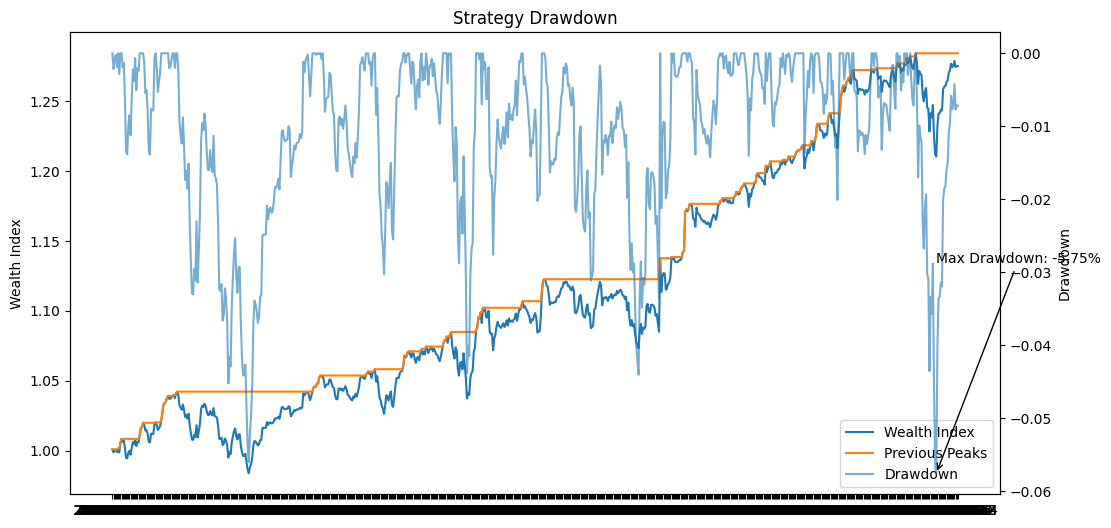

{'wealth_index': Date
 2023-05-05    1.000945
 2023-05-08    0.998790
 2023-05-09    1.000229
 2023-05-10    1.000732
 2023-05-11    0.999071
                 ...   
 2026-04-20    1.275026
 2026-04-21    1.278793
 2026-04-22    1.274344
 2026-04-23    1.275041
 2026-04-24    1.275041
 Length: 745, dtype: float64,
 'previous_peaks': Date
 2023-05-05    1.000945
 2023-05-08    1.000945
 2023-05-09    1.000945
 2023-05-10    1.000945
 2023-05-11    1.000945
                 ...   
 2026-04-20    1.284237
 2026-04-21    1.284237
 2026-04-22    1.284237
 2026-04-23    1.284237
 2026-04-24    1.284237
 Length: 745, dtype: float64,
 'drawdowns': Date
 2023-05-05    0.000000
 2023-05-08   -0.002154
 2023-05-09   -0.000716
 2023-05-10   -0.000213
 2023-05-11   -0.001872
                 ...   
 2026-04-20   -0.007172
 2026-04-21   -0.004240
 2026-04-22   -0.007704
 2026-04-23   -0.007161
 2026-04-24   -0.007161
 Length: 745, dtype: float64,
 'max_drawdown': np.float64(-0.05753858589222258),
 '

In [29]:
plot_drawdown(LSTMdailyReturns)

In [30]:
LRprobabilities = pd.DataFrame(LRprobabilities)
XGProbabilities = pd.DataFrame(XGProbabilities)
LSTMProbs = pd.DataFrame(LSTMProbs)

avgProbs = (LRprobabilities + XGProbabilities + LSTMProbs) / 3
avgProbs = avgProbs.to_dict(orient='list')


In [31]:
avgTrades, AvgTradesAGG = getTrades(avgProbs)

avgDailyReturns = avgTrades.sum(axis=1) / AvgTradesAGG
avgDailyReturns = avgDailyReturns.fillna(0)

avgSharpeRatio = getSharpeRatio(avgDailyReturns.values)
avgSharpeRatio

np.float64(1.3225054766685003)

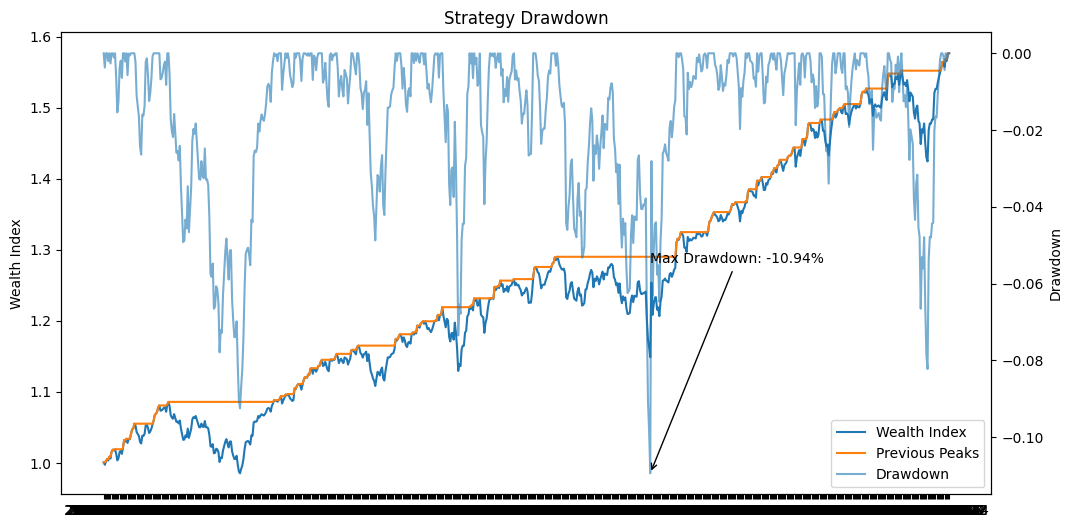

{'wealth_index': Date
 2023-05-05    1.001134
 2023-05-08    0.997422
 2023-05-09    1.002248
 2023-05-10    1.005468
 2023-05-11    1.003436
                 ...   
 2026-04-20    1.557399
 2026-04-21    1.568501
 2026-04-22    1.565965
 2026-04-23    1.576481
 2026-04-24    1.576481
 Length: 745, dtype: float64,
 'previous_peaks': Date
 2023-05-05    1.001134
 2023-05-08    1.001134
 2023-05-09    1.002248
 2023-05-10    1.005468
 2023-05-11    1.005468
                 ...   
 2026-04-20    1.564244
 2026-04-21    1.568501
 2026-04-22    1.568501
 2026-04-23    1.576481
 2026-04-24    1.576481
 Length: 745, dtype: float64,
 'drawdowns': Date
 2023-05-05    0.000000
 2023-05-08   -0.003707
 2023-05-09    0.000000
 2023-05-10    0.000000
 2023-05-11   -0.002021
                 ...   
 2026-04-20   -0.004376
 2026-04-21    0.000000
 2026-04-22   -0.001617
 2026-04-23    0.000000
 2026-04-24    0.000000
 Length: 745, dtype: float64,
 'max_drawdown': np.float64(-0.10944106090321144),
 '

In [32]:
plot_drawdown(avgDailyReturns)